### This notebook provides a high-level descriptive overview of the dataset to establish context, validate data integrity, and set baselines for subsequent analyses.

In [8]:
import os

# Where Python thinks we are
print("Current working directory:", os.getcwd())

# List all files in your folder
print(os.listdir("C:/Users/Admin/Desktop/olist-project/data/processed"))


Current working directory: c:\Users\Admin\OneDrive\Desktop\olist-capstone-project\notebooks


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:/Users/Admin/Desktop/olist-project/data/processed'

In [12]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# -------------------------
# Dataset A: Order-level
# -------------------------
order_path = Path(r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_order_level.csv")

orders = pd.read_csv(
    order_path,
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

print("Order-level dataset sample:")
print(orders.head())

# -------------------------
# Dataset B: Item-level
# -------------------------
item_path = Path(r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_item_level.csv")

items = pd.read_csv(item_path)
print("\nItem-level dataset sample:")
print(items.head())

Order-level dataset sample:
                           order_id                       customer_id  \
0  00010242fe8c5a6d1ba2dd792cb16214  3ce436f183e68e07877b285a838db11a   
1  00018f77f2f0320c557190d7a144bdd3  f6dd3ec061db4e3987629fe6b26e5cce   
2  000229ec398224ef6ca0657da4fc703e  6489ae5e4333f3693df5ad4372dab6d3   
3  00024acbcdf0a6daa1e931b038114c75  d4eb9395c8c0431ee92fce09860c5a06   
4  00042b26cf59d7ce69dfabb4e55b4fd9  58dbd0b2d70206bf40e62cd34e84d795   

  customer_state          customer_city  customer_zip_code_prefix  \
0             RJ  campos dos goytacazes                     28013   
1             SP        santa fe do sul                     15775   
2             MG          para de minas                     35661   
3             SP                atibaia                     12952   
4             SP        varzea paulista                     13226   

  order_status order_purchase_timestamp order_delivered_customer_date  \
0    delivered      2017-09-13 08:59:02      

### 2.1 Dataset Scope

In [13]:
# ----- Order-level summary -----
total_orders = orders.shape[0]
start_date = orders['order_purchase_timestamp'].min()
end_date = orders['order_purchase_timestamp'].max()
total_customers = orders['customer_id'].nunique()

# ----- Item-level summary (sellers & categories) -----
total_sellers = items['seller_id'].nunique()
total_categories = items['product_category_name'].nunique()

print(f"Total orders: {total_orders}")
print(f"Date range: {start_date.date()} to {end_date.date()}")
print(f"Unique customers: {total_customers}")
print(f"Unique sellers: {total_sellers}")
print(f"Unique product categories: {total_categories}")


Total orders: 99441
Date range: 2016-09-04 to 2018-10-17
Unique customers: 99441
Unique sellers: 3095
Unique product categories: 74


- The dataset contains 99441 orders placed between 2016-09-04  and 2018-10-17, involving Y customers and Z sellers across multiple product categories. 

### 2.2 Order Status Distribution

Before analyzing delivery delays, we must know:

How many orders were actually delivered?

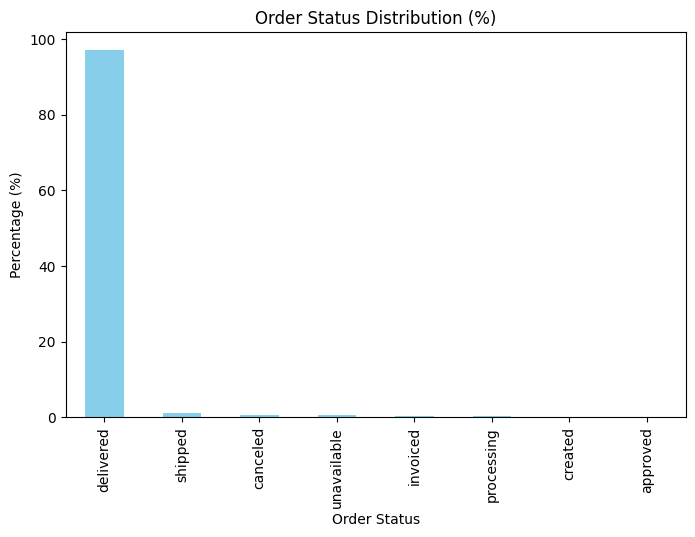

In [ ]:
order_status_pct = orders["order_status"].value_counts(normalize=True).mul(100)

order_status_pct 

# Visualise
order_status_pct.plot(kind="bar", color="skyblue", figsize=(8, 5))
plt.title("Order Status Distribution (%)")
plt.ylabel("Percentage (%)")
plt.xlabel("Order Status")  
plt.show()


#remebr to get the statistics


- Most orders are delivered, indicating operational reliability.

### 2.3 Revenue & Order Value Overview

We check:

Order value scale

Skewness (important later)

Total revenue: 15876443.27
Average order value: 159.66
Median order value: 104.72


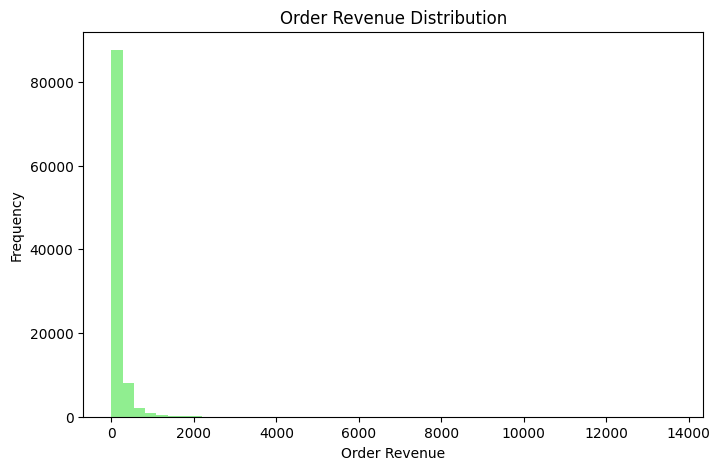

In [17]:
total_revenue = orders["total_revenue"].sum()
average_order_value = orders["total_revenue"].mean()
median_order_value = orders["total_revenue"].median()

print(f"Total revenue: {total_revenue:.2f}")
print(f"Average order value: {average_order_value:.2f}")
print(f"Median order value: {median_order_value:.2f}")

# Revenue distirbution
orders['total_revenue'].plot(kind='hist', bins=50, color='lightgreen', figsize=(8, 5))
plt.title("Order Revenue Distribution")
plt.xlabel("Order Revenue")
plt.show()

- Distribution is right-skewed; high-value orders inflate the mean.

### 2.4 Delivery Performance Overview

Average delivery time (days): 12.09
Median delivery time (days): 10.00


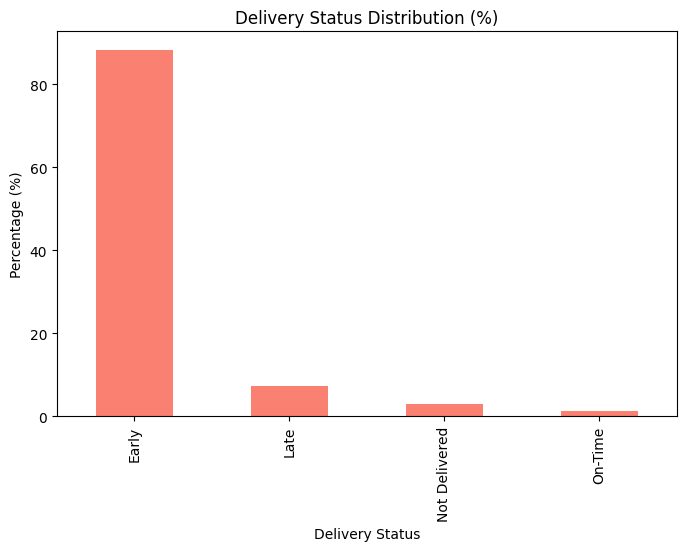

In [19]:
avrg_delivery_time = orders["delivery_time_days"].mean()
median_delivery_time = orders["delivery_time_days"].median()

print(f"Average delivery time (days): {avrg_delivery_time:.2f}")
print(f"Median delivery time (days): {median_delivery_time:.2f}")

delivery_status_pct =orders["delivery_status"].value_counts(normalize=True).mul(100)
delivery_status_pct.plot(kind="bar", color="salmon", figsize=(8, 5))
plt.title("Delivery Status Distribution (%)")
plt.ylabel("Percentage (%)")
plt.xlabel("Delivery Status")
plt.show()

- Most orders are delivered on-time or early; delayed orders will be analyzed later by region, seller, and category.

* note thsi and repair or check

In [ ]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"] - 
    orders["order_estimated_delivery_date"]
).dt.days

delivery_status = pd.cut(
    orders["delivery_delay_days"],
    bins=[-np.inf, 0, np.inf],
    labels=["On-time/Early", "Late"]
)

delivery_status.value_counts(normalize=True) * 100


delivery_delay_days
On-time/Early    93.226295
Late              6.773705
Name: proportion, dtype: float64

### 2.5 Review Score Overview

Average review score: 4.09


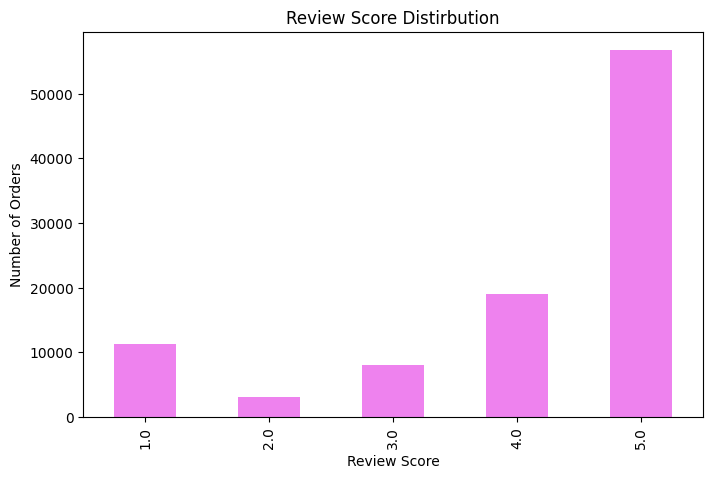

In [21]:
avg_review_score = orders["review_score"].mean()
print(f"Average review score: {avg_review_score:.2f}")

review_dist = orders["review_score"].value_counts().sort_index()
review_dist.plot(kind="bar", color="violet", figsize=(8, 5))
plt.title("Review Score Distirbution")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.show()

- Most reviews are high, though lower ratings exist, which will be correlated with delivery performance in later notebooks

### 2.7: Order Composition Overview

In [22]:
avg_items_per_order = orders['items_per_order'].mean()
median_items_per_order = orders["items_per_order"].median()

print(f"Average items per order: {avg_items_per_order:.2f}")
print(f"Median items per order: {median_items_per_order:.2f}")

Average items per order: 1.14
Median items per order: 1.00
